# What We Are GOing to DOOO!!

## Steps
# 0. Preprocess + EDA + Feature Selection
•	# 1. Extract input and output cols
•	# 2. Scale the values
•	# 3. Train test split
•	# 4. Train the model
•	# 5. Evaluate the model/model selection
•	# 6. Deploy the model

In [171]:
import numpy as np
import pandas as pd


In [172]:
df = pd.read_csv("college_student_placement_dataset.csv")
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [173]:
df.shape

(10000, 10)

In [174]:
df.ndim

2

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  str    
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  str    
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(3)
memory usage: 894.3 KB


In [176]:
import matplotlib.pyplot as plt

In [177]:
#plt.scatter(df["CGPA"], df["IQ"], c= df['Placement'])



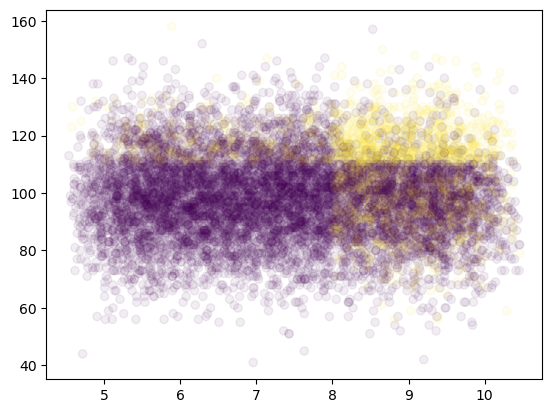

In [178]:
plt.scatter(df["CGPA"], df["IQ"], c = df["Placement"].map({"Yes":1, "No":0}), alpha=0.07)

In [179]:
#plt.bar( "CGPA" , "IQ" ,"Placement", color = ["rainbow"])

In [180]:
#df.groupby("Placement")["CGPA"].mean().plot(kind= "bar", color = ["Pink", "Skyblue"])

In [181]:
df_subset = df.iloc[ : ,[1,3,9]]
df_subset

,IQ,CGPA,Placement
0,107,6.28,No
1,97,5.37,No
2,109,5.83,No
3,122,5.75,No
4,96,7.69,No
...,...,...,...
9995,119,8.29,Yes
9996,70,9.34,No
9997,89,6.25,No
9998,107,8.92,No


In [182]:
x = df_subset.iloc[:,[0,1]]
y = df_subset.iloc[: , -1]
y = y.map({'Yes': 1, 'No': 0})

In [183]:
x

,IQ,CGPA
0,107,6.28
1,97,5.37
2,109,5.83
3,122,5.75
4,96,7.69
...,...,...
9995,119,8.29
9996,70,9.34
9997,89,6.25
9998,107,8.92


In [184]:
y

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: Placement, Length: 10000, dtype: int64

In [185]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y ,  test_size = 0.1)

In [186]:
x_train

,IQ,CGPA
2691,96,6.32
871,88,6.66
4973,68,7.48
3363,79,6.43
352,112,8.14
...,...,...
6205,123,5.08
5678,105,8.52
3930,110,8.63
159,109,5.47


In [187]:
y_train

2691    0
871     0
4973    0
3363    0
352     0
       ..
6205    0
5678    1
3930    0
159     0
7877    0
Name: Placement, Length: 9000, dtype: int64

In [188]:
x_test

,IQ,CGPA
3554,72,6.78
8534,118,9.81
7320,109,6.15
2815,112,8.80
9047,99,5.91
...,...,...
8345,104,5.10
6455,84,10.35
1352,108,8.98
1222,109,9.14


In [189]:
y_test

3554    0
8534    1
7320    0
2815    1
9047    0
       ..
8345    0
6455    0
1352    0
1222    0
3051    0
Name: Placement, Length: 1000, dtype: int64

In [190]:
from sklearn.preprocessing import StandardScaler

In [191]:
scaler = StandardScaler()

In [192]:
x_train = scaler.fit_transform(x_train)

In [193]:
x_train

array([[-0.23078419, -0.8195306 ],
       [-0.76390987, -0.58821484],
       [-2.09672408, -0.03033563],
       ...,
       [ 0.70218576,  0.75205595],
       [ 0.63554505, -1.39782003],
       [ 0.3023415 ,  0.84050021]], shape=(9000, 2))

In [194]:
x_test = scaler.transform(x_test)

In [195]:
x_test

array([[-1.83016124, -0.50657398],
       [ 1.23531145,  1.55485773],
       [ 0.63554505, -0.93518849],
       ...,
       [ 0.56890434,  0.99017512],
       [ 0.63554505,  1.0990296 ],
       [-0.69726916,  0.99017512]], shape=(1000, 2))

In [196]:
from sklearn.linear_model import LogisticRegression

In [197]:
clf = LogisticRegression()

# Model Training

In [198]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [199]:
y_pred =clf.predict(x_test)

In [200]:
y_test

3554    0
8534    1
7320    0
2815    1
9047    0
       ..
8345    0
6455    0
1352    0
1222    0
3051    0
Name: Placement, Length: 1000, dtype: int64

## Accuracy Testing

In [201]:
from sklearn.metrics import accuracy_score

In [202]:
accuracy_score(y_test, y_pred)

0.843

# 84.7 % accuracy 

In [203]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

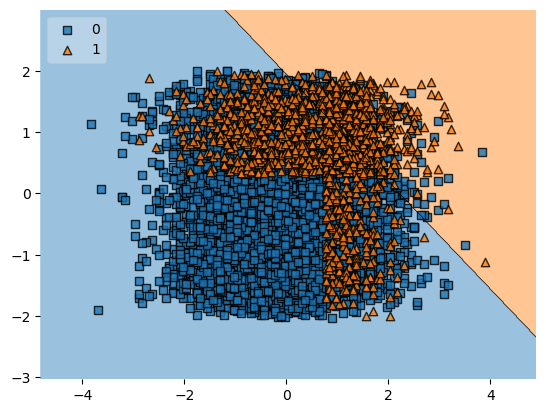

In [204]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [205]:
import pickle

In [207]:
pickle.dump(clf,open("model.pkl", "wb"))

In [208]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)